In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,5/16/2023,CUST996,Male,62,Clothing,1,50,50
996,997,11/17/2023,CUST997,Male,52,Beauty,3,30,90
997,998,10/29/2023,CUST998,Female,23,Beauty,4,25,100
998,999,12/5/2023,CUST999,Female,36,Electronics,3,50,150


In [ ]:
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
#Descprtv Stats

In [ ]:
df1= df['Total Amount'].mean()
df1

np.float64(456.0)

In [ ]:
df2=df['Total Amount'].median()
df2


135.0

In [ ]:
df3=df['Total Amount'].mode()
df3

,Total Amount
0,50


In [ ]:
df4=df['Total Amount'].std()
df4

559.997631555123

In [ ]:
#Time Series Analysis!

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df['Year']=df['Date'].dt.year
df['Year']

,Year
0,2023
1,2023
2,2023
3,2023
4,2023
...,...
995,2023
996,2023
997,2023
998,2023


In [ ]:
df['Month']=df['Date'].dt.month
df['Month']

,Month
0,11
1,2
2,1
3,5
4,5
...,...
995,5
996,11
997,10
998,12


In [ ]:
df['Day']=df['Date'].dt.day
df['Day']

,Day
0,24
1,27
2,13
3,21
4,6
...,...
995,16
996,17
997,29
998,5


In [ ]:
#Monthly sales analysis!

In [ ]:
monthly_sales=df.groupby('Month')['Total Amount'].sum()
monthly_sales

,Total Amount
Month,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


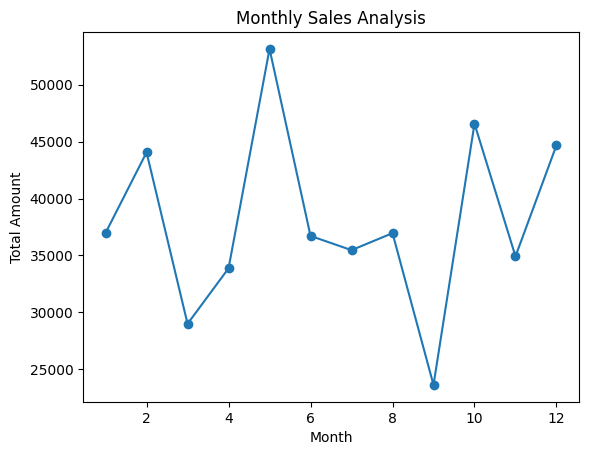

In [ ]:
import matplotlib.pyplot as plt
monthly_sales.plot(kind='line',marker='o')
plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.show()

,Total Amount
Year,
2023,454470
2024,1530


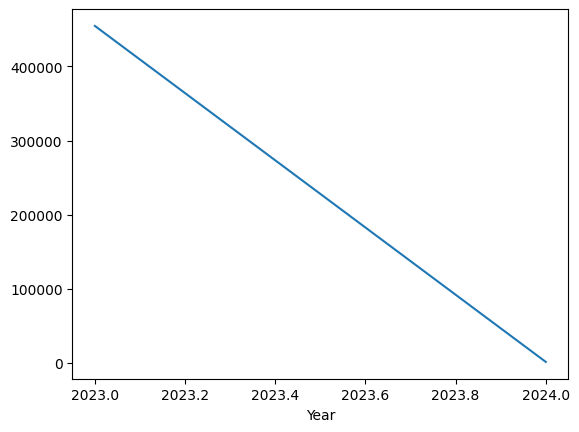

In [ ]:
yearly_sales=df.groupby('Year')['Total Amount'].sum()
yearly_sales.plot(kind='line')
yearly_sales

,Total Amount
Day,
1,23680
2,13965
3,9000
4,14150
5,18365
6,19675
7,13335
8,17190
9,15470


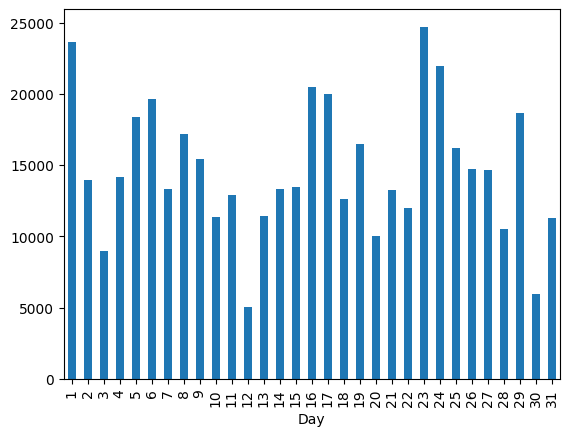

In [ ]:
daily_sales=df.groupby('Day')['Total Amount'].sum()
daily_sales.plot(kind='bar')
daily_sales

In [ ]:
#customer product analysis

In [ ]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [ ]:
df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False).head(10)

,Total Amount
Gender,
Female,232840
Male,223160


In [ ]:
df.groupby('Product Category')[['Quantity','Total Amount']].sum()

,Quantity,Total Amount
Product Category,,
Beauty,771,143515
Clothing,894,155580
Electronics,849,156905


In [ ]:
df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

,Total Amount
Customer ID,
High,363600
Low,92400


In [ ]:
df.groupby('Customer ID')['Total Amount'].mean()

,Total Amount
Customer ID,
CUST001,150.0
CUST002,1000.0
CUST003,30.0
CUST004,500.0
CUST005,100.0
...,...
CUST995,30.0
CUST996,50.0
CUST997,90.0


In [ ]:
df['Customer ID'] =df['Total Amount'].apply(lambda x: 'High' if x>500 else 'Low')
df['Customer ID']

,Customer ID
0,Low
1,High
2,Low
3,Low
4,Low
...,...
995,Low
996,Low
997,Low
998,Low


In [ ]:
#Data Vizs!

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

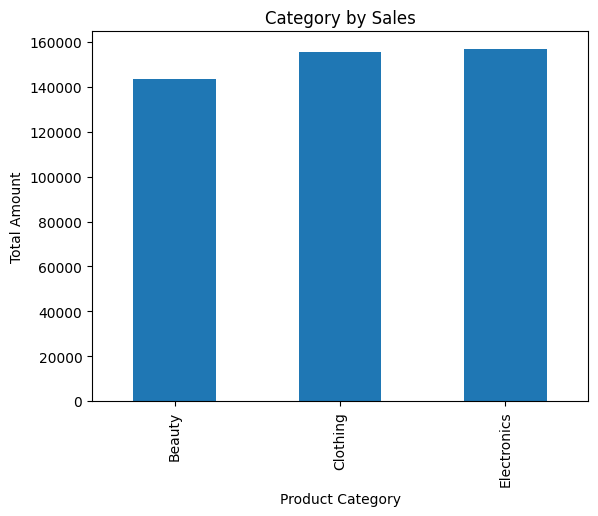

In [ ]:
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')
plt.title("Category by Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

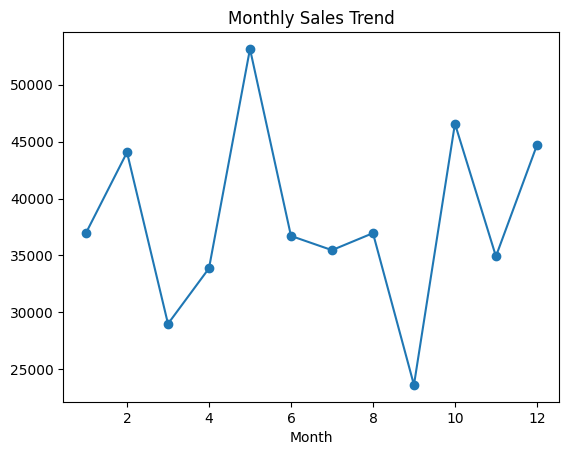

In [ ]:
df.groupby('Month')['Total Amount'].sum().plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

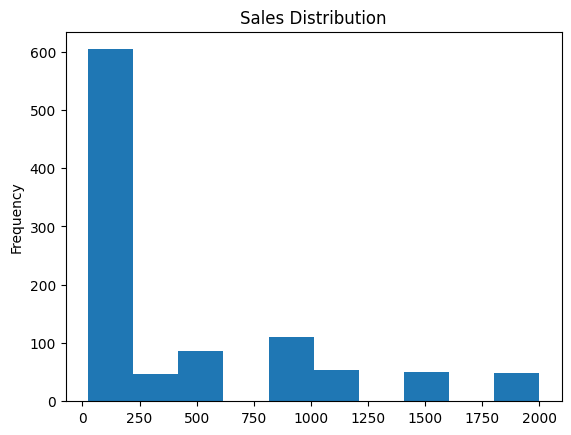

In [ ]:
df['Total Amount'].plot(kind='hist')
plt.title("Sales Distribution")
plt.show()

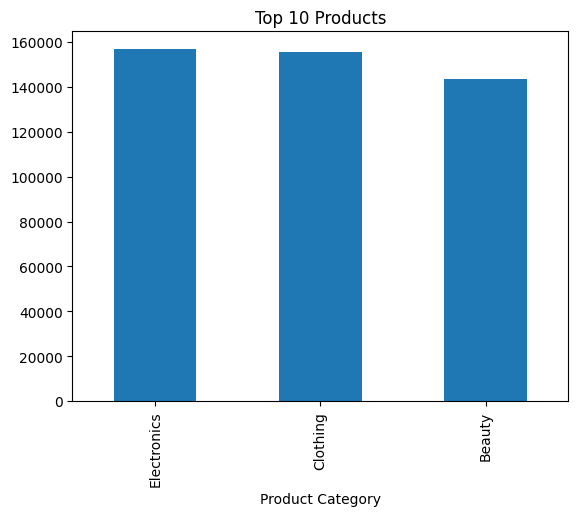

In [ ]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

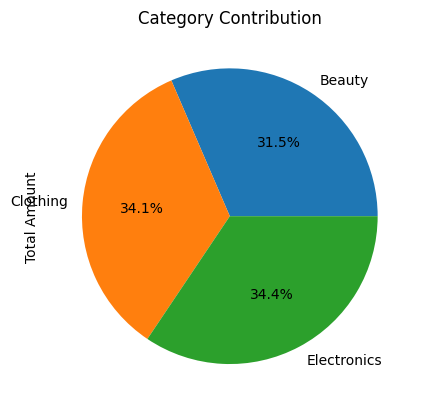

In [ ]:
df.groupby('Product Category')['Total Amount'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Contribution")
plt.show()

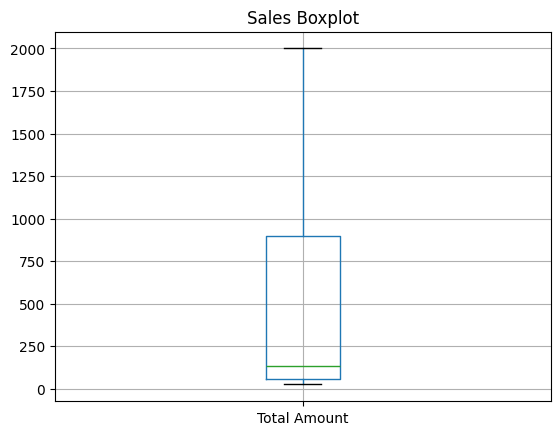

In [ ]:
df.boxplot(column='Total Amount')
plt.title("Sales Boxplot")
plt.show()